<a href="https://colab.research.google.com/github/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised/blob/main/erps_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trial-level ERP analysis of sentence-final expectancy and semantic integration

This notebook runs the ERP part of the Toffolo et al. (2022) N400Stimset reanalysis. The original study tested ERP responses to sentence-final congruent and incongruent words, with effects reported for the Recognition Potential (RP), N400, and Late Positive Component (LPC/P600). The present analysis keeps the sentence-final ERP focus and uses the predictor table created in the stimulus notebook to model retained ERP/EEG trials at the trial level.

This notebook belongs to the GitHub repository for the Toffolo et al. language reanalysis:  
[https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised](https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised)

The stimulus notebook created the GLM-ready table of item-level predictors. That table keeps `stim_key` as the stimulus identifier and contains predictors for each sentence-final target word, including human cloze probability, GPT-2 surprisal, LLM-derived expectancy, semantic similarity, lexical frequency, word length, phonology, syntactic complexity, and affective features.

This ERP notebook uses the processed N400Stimset ERP derivatives and epoched EEG files: subject-level ERP `.mat` files, paired `*_trialrej.tsv` files, subject event information, and EEGLAB epoch files for the CP, GA, LD, Order, and Time analysis schemes. These files contain the retained trials after preprocessing and rejection.

The notebook runs three scripts. `erp_analysis/export_erp_long.py` creates `ALL_subjects_ALL_erp_trial_lookup.tsv`, a retained-trial lookup that records the subject, analysis scheme, condition, retained-trial number, EEGLAB event information, original event row, stimulus file, and `stim_key` for every retained ERP trial. `eeg_analysis/prepare_limo_design_matrix.py` uses that lookup to create subject-specific GLM design matrices by attaching the stimulus predictors through `stim_key`. `eeg_analysis/run_limo_first_level_glm.py` pairs each subject’s epoched EEG file with the matching design matrix and estimates beta and t values for the selected predictors across channels and timepoints.

The outputs of this notebook are the retained-trial lookup, the subject-specific GLM design matrices, and the first-level EEG/ERP GLM results. These outputs test whether sentence-final expectancy, surprisal, semantic fit, lexical properties, phonological structure, syntactic complexity, and affective tone explain variation in RP, N400/PN400, and LPC/P600 activity.

In [14]:
%cd /content

!rm -rf Semantically_Incongruent_or_Congruent_Eggplants_revised
!git clone https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised.git

%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

/content
Cloning into 'Semantically_Incongruent_or_Congruent_Eggplants_revised'...
remote: Enumerating objects: 434, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 434 (delta 102), reused 59 (delta 35), pack-reused 280 (from 1)
Receiving objects: 100% (434/434), 94.82 MiB | 28.58 MiB/s, done.
Resolving deltas: 100% (250/250), done.
/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


In [15]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 26.0 MB/s eta 0:00:00


In [16]:
!unzip language_outputs.zip

Archive:  language_outputs.zip
   creating: language_outputs/
  inflating: language_outputs/ALL_language_metrics.tsv  
  inflating: language_outputs/ALL_predictor_diagnostics_vif.tsv  
  inflating: language_outputs/ALL_predictor_diagnostics_correlations.tsv  
  inflating: language_outputs/ALL_language_metrics_GLM.tsv  


**Note**: Due to their size, the N400 ERP derivatives are stored on Google Drive and mounted during notebook execution.

In [17]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o erps.zip

Archive:  erps.zip
  inflating: erps/task-N400Stimset_erp-CP_trialrej.json  
  inflating: erps/task-N400Stimset_erp-GA_filter.json  
  inflating: erps/task-N400Stimset_erp-GA_trialrej.json  
  inflating: erps/task-N400Stimset_erp-LD_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Order_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Time_trialrej.json  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Time.mat  
  inflating: erps/sub-01/sub

In [18]:
%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


# Export retained ERP trials

This section creates the retained-trial lookup used to connect the ERP data with the stimulus predictors.

The export script reads the ERP `.mat` files, the matching `*_trialrej.tsv` files, the subject event information, and the stimulus lookup. It runs across the CP, GA, LD, Order, and Time analysis schemes.

The output is:

`ALL_subjects_ALL_erp_trial_lookup.tsv`

For each retained ERP trial, the table stores the subject, analysis scheme, condition, retained-trial number, event information, stimulus file, and `stim_key`.

In [19]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/drive/MyDrive/N400/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze Probability < 80 % - 43 before rejec

term,meaning
Condition retention %,Percentage of trials retained after artifact rejection for one exported condition.
Condition imbalance,"Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file."
Difference from analysis mean,How far each condition's retention is above or below the average retention of its own analysis.


subject,analysis,plot_label,condition_label,retained_trial,stimulus_row,stim_key,trial_type
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,1,17,sound17,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,2,23,sound23,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,3,133,sound133,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,4,164,sound164,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,5,215,sound215,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,6,345,sound345,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,7,351,sound351,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,8,357,sound357,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,9,381,sound381,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,10,414,sound414,NPC


plot_label,condition_label
CP C1,Congruent: Cloze Probability ≥ 96 %
CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %
CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %
CP C4,Congruent: Cloze Probability < 80 %
CP C5,Incongruent: Cloze Probability ≥ 96 %
CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %
CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %
CP C8,Incongruent: Cloze Probability < 80 %
GA C1,Congruent
GA C2,Incongruent


plot_label,mean_pct,sd_pct,min_pct,max_pct,diff_from_analysis_mean_pp
CP C1,84.81,15.99,40.74,98.15,-0.79
CP C2,85.98,13.50,48.21,98.21,0.38
CP C3,85.21,14.42,53.19,97.87,-0.39
CP C4,84.53,17.63,32.56,100.00,-1.07
CP C5,86.64,16.82,34.55,100.00,1.04
CP C6,86.70,12.69,55.36,98.21,1.10
CP C7,83.94,16.06,40.43,95.74,-1.66
CP C8,87.02,14.11,54.76,100.00,1.42
GA C1,83.39,17.85,34.09,99.00,-0.21
GA C2,83.81,17.76,35.91,97.27,0.21


analysis,mean_imbalance_pp,sd_imbalance_pp,min_imbalance_pp,max_imbalance_pp
CP,13.15,6.21,4.73,26.37
GA,3.06,2.72,0.00,9.00
LD,7.38,3.54,1.91,14.79
Order,8.10,6.21,1.88,28.28
Time,17.71,12.37,5.46,53.53


statistic,value
Retained ERP-trial rows,35751.00
Subjects represented,24.00
Analyses represented,5.00
ERP MAT files represented,104.00
Unique stimulus keys,442.00
Unique stimulus files,442.00
Missing stim_key,0.00
Missing stim_file,0.00
Stimulus row minimum,1.00
Stimulus row maximum,442.00


analysis,congruence_group,mean_pct,sd_pct,min_pct,max_pct
CP,Congruent,85.14,15.18,32.56,100.00
CP,Incongruent,86.07,14.77,34.55,100.00
GA,Congruent,83.39,17.85,34.09,99.00
GA,Incongruent,83.81,17.76,35.91,97.27
LD,Congruent,85.87,15.28,42.03,100.00
LD,Incongruent,86.97,14.43,46.56,100.00
Order,Incongruent,86.54,14.90,42.42,101.02
Time,Congruent,86.06,16.27,25.00,101.96
Time,Incongruent,87.04,15.69,28.57,102.04


congruence_group,analysis,congruent_minus_incongruent_pp
,CP,-0.93
,GA,-0.42
,LD,-1.10
,Order,NaN
,Time,-0.98


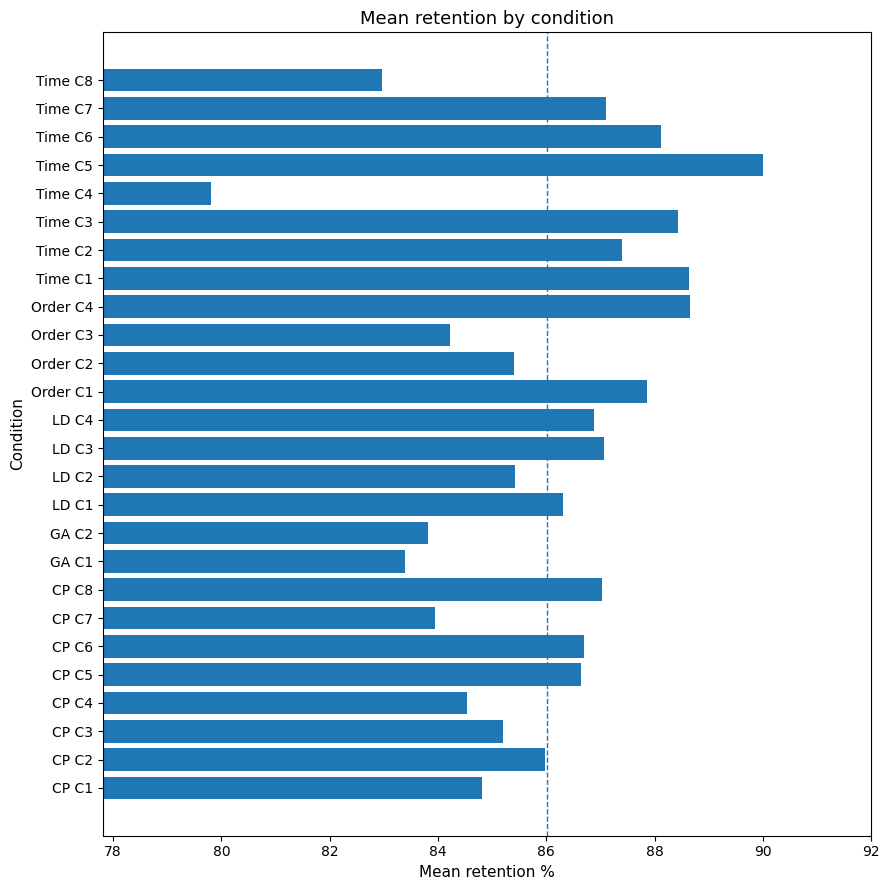

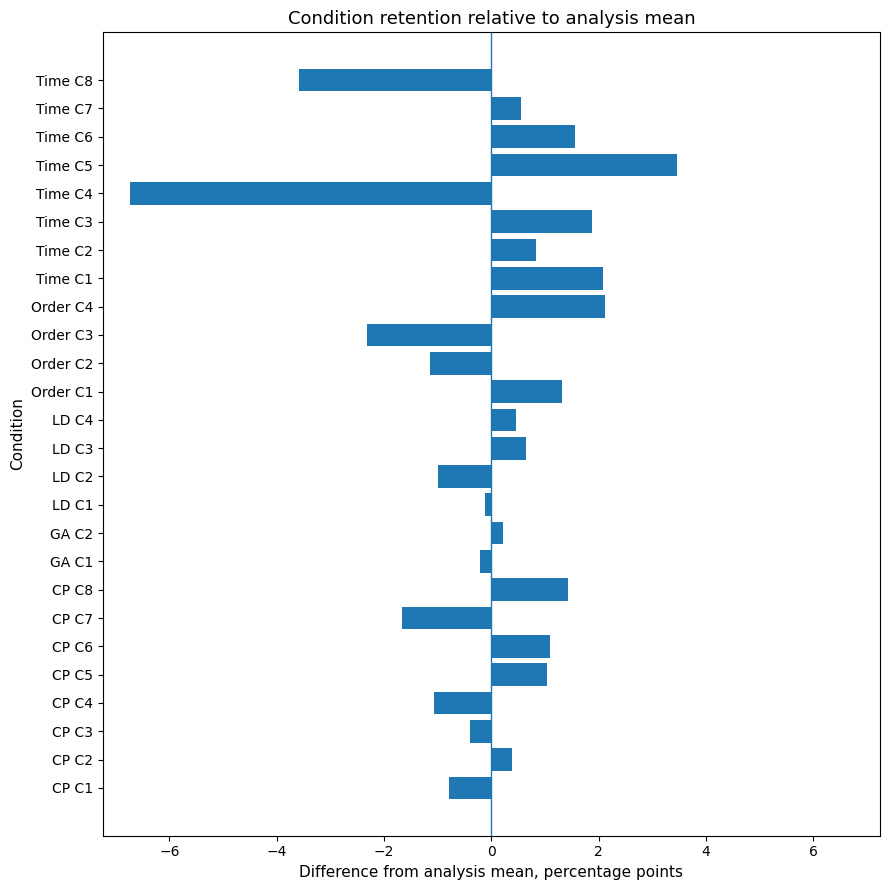

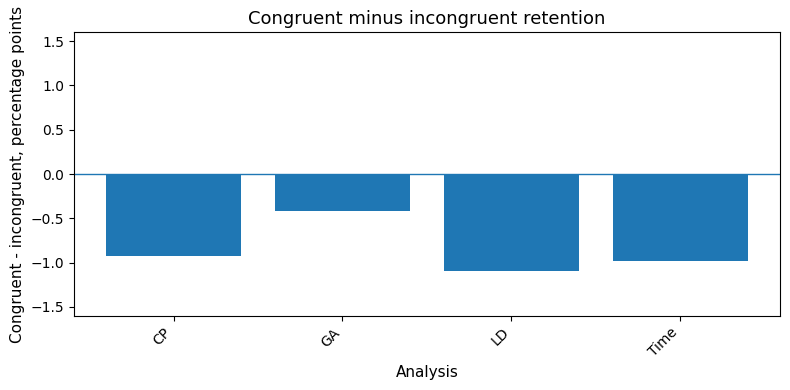

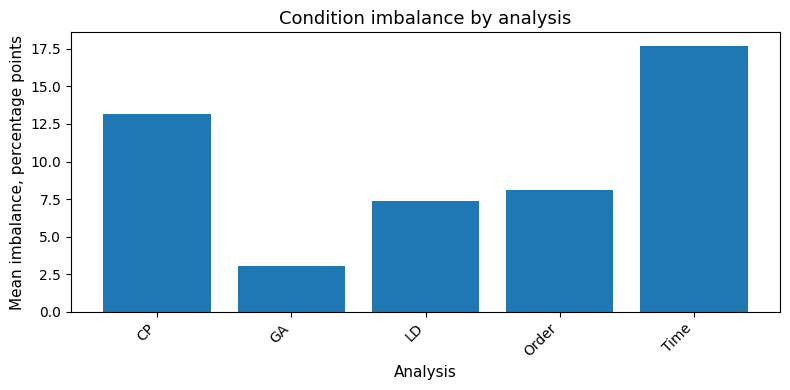

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ============================================================
# Input
# ============================================================

lookup_path = "/content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
lookup = pd.read_csv(lookup_path, sep="\t")

# ============================================================
# Plot text sizes
# ============================================================

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ============================================================
# Display helper
# ============================================================

def show_table(df, title=None, max_height="420px"):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
            }}
        </style>
        {html}
    </div>
    """))

display(HTML("""
<h2 style="font-weight: bold; margin-bottom: 16px;">
ERP lookup export: first rows and statistical QC
</h2>
"""))

# ============================================================
# Build condition-level dataset
# ============================================================

condition_cells = (
    lookup[
        [
            "subject",
            "analysis",
            "source_file",
            "condition",
            "condition_label",
            "before_trial_rejection",
            "after_trial_rejection_mat",
        ]
    ]
    .drop_duplicates()
    .copy()
)

condition_cells["retention_pct"] = (
    condition_cells["after_trial_rejection_mat"]
    / condition_cells["before_trial_rejection"]
    * 100
)

condition_cells["plot_label"] = (
    condition_cells["analysis"].astype(str)
    + " C"
    + condition_cells["condition"].astype(str)
)

def get_congruence_group(label):
    label = str(label).lower()

    if "incongruent" in label or "inongruent" in label:
        return "Incongruent"

    if "congruent" in label:
        return "Congruent"

    return "Other"

condition_cells["congruence_group"] = condition_cells["condition_label"].apply(
    get_congruence_group
)

# ============================================================
# QC meaning table
# ============================================================

meaning_table = pd.DataFrame(
    {
        "term": [
            "Condition retention %",
            "Condition imbalance",
            "Difference from analysis mean",
        ],
        "meaning": [
            "Percentage of trials retained after artifact rejection for one exported condition.",
            "Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file.",
            "How far each condition's retention is above or below the average retention of its own analysis.",
        ],
    }
)

show_table(
    meaning_table,
    "QC term meanings",
)

# ============================================================
# 1. First rows of exported lookup
# ============================================================

first_rows = lookup[
    [
        "subject",
        "analysis",
        "condition",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
].head(15).copy()

first_rows["plot_label"] = (
    first_rows["analysis"].astype(str)
    + " C"
    + first_rows["condition"].astype(str)
)

first_rows = first_rows[
    [
        "subject",
        "analysis",
        "plot_label",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
]

show_table(
    first_rows,
    "1. First rows of exported lookup",
)

# ============================================================
# 2. Condition-label key for plot labels
# ============================================================

condition_key = (
    lookup[
        [
            "analysis",
            "condition",
            "condition_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(["analysis", "condition"])
    .reset_index(drop=True)
)

condition_key["plot_label"] = (
    condition_key["analysis"].astype(str)
    + " C"
    + condition_key["condition"].astype(str)
)

condition_key = condition_key[
    [
        "plot_label",
        "condition_label",
    ]
]

show_table(
    condition_key,
    "2. Condition-label key for plot labels",
)

# ============================================================
# 3. Retention statistics by condition
# ============================================================

condition_stats = (
    condition_cells
    .groupby(["analysis", "condition", "plot_label"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "condition"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    condition_stats[col] = condition_stats[col].round(2)

analysis_mean_retention = (
    condition_cells
    .groupby("analysis")["retention_pct"]
    .mean()
    .reset_index(name="analysis_mean_pct")
)

condition_stats = condition_stats.merge(
    analysis_mean_retention,
    on="analysis",
    how="left",
)

condition_stats["diff_from_analysis_mean_pp"] = (
    condition_stats["mean_pct"]
    - condition_stats["analysis_mean_pct"]
).round(2)

condition_stats_compact = condition_stats[
    [
        "plot_label",
        "mean_pct",
        "sd_pct",
        "min_pct",
        "max_pct",
        "diff_from_analysis_mean_pp",
    ]
]

show_table(
    condition_stats_compact,
    "3. Retention statistics by condition",
)

# ============================================================
# 4. Condition imbalance statistics by analysis
# ============================================================

condition_imbalance_by_file_analysis = (
    condition_cells
    .groupby(["subject", "analysis", "source_file"])["retention_pct"]
    .agg(
        min_retention_pct="min",
        max_retention_pct="max",
    )
    .reset_index()
)

condition_imbalance_by_file_analysis["condition_imbalance_pp"] = (
    condition_imbalance_by_file_analysis["max_retention_pct"]
    - condition_imbalance_by_file_analysis["min_retention_pct"]
)

imbalance_stats = (
    condition_imbalance_by_file_analysis
    .groupby("analysis")["condition_imbalance_pp"]
    .agg(
        mean_imbalance_pp="mean",
        sd_imbalance_pp="std",
        min_imbalance_pp="min",
        max_imbalance_pp="max",
    )
    .reset_index()
    .sort_values("analysis")
)

for col in [
    "mean_imbalance_pp",
    "sd_imbalance_pp",
    "min_imbalance_pp",
    "max_imbalance_pp",
]:
    imbalance_stats[col] = imbalance_stats[col].round(2)

show_table(
    imbalance_stats,
    "4. Condition imbalance statistics by analysis",
)

# ============================================================
# 5. Overall statistical QC summary
# ============================================================

overall_summary = pd.DataFrame(
    {
        "statistic": [
            "Retained ERP-trial rows",
            "Subjects represented",
            "Analyses represented",
            "ERP MAT files represented",
            "Unique stimulus keys",
            "Unique stimulus files",
            "Missing stim_key",
            "Missing stim_file",
            "Stimulus row minimum",
            "Stimulus row maximum",
            "Mean condition retention %",
            "SD condition retention %",
            "Minimum condition retention %",
            "Maximum condition retention %",
            "Mean condition imbalance, percentage points",
            "Maximum condition imbalance, percentage points",
        ],
        "value": [
            len(lookup),
            lookup["subject"].nunique(),
            lookup["analysis"].nunique(),
            lookup["source_file"].nunique(),
            lookup["stim_key"].nunique(),
            lookup["stim_file"].nunique(),
            int(lookup["stim_key"].isna().sum()),
            int(lookup["stim_file"].isna().sum()),
            int(lookup["stimulus_row"].min()),
            int(lookup["stimulus_row"].max()),
            round(condition_cells["retention_pct"].mean(), 2),
            round(condition_cells["retention_pct"].std(), 2),
            round(condition_cells["retention_pct"].min(), 2),
            round(condition_cells["retention_pct"].max(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].mean(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].max(), 2),
        ],
    }
)

show_table(
    overall_summary,
    "5. Overall statistical QC summary",
)

# ============================================================
# 6. Congruent vs incongruent retention statistics
# ============================================================

congruence_stats = (
    condition_cells[
        condition_cells["congruence_group"].isin(["Congruent", "Incongruent"])
    ]
    .groupby(["analysis", "congruence_group"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "congruence_group"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    congruence_stats[col] = congruence_stats[col].round(2)

show_table(
    congruence_stats,
    "6. Congruent vs incongruent retention statistics",
)

congruence_pivot = (
    congruence_stats
    .pivot(
        index="analysis",
        columns="congruence_group",
        values="mean_pct",
    )
    .sort_index()
)

if "Congruent" in congruence_pivot.columns and "Incongruent" in congruence_pivot.columns:
    congruence_pivot["congruent_minus_incongruent_pp"] = (
        congruence_pivot["Congruent"]
        - congruence_pivot["Incongruent"]
    )
else:
    congruence_pivot["congruent_minus_incongruent_pp"] = np.nan

congruence_difference_table = (
    congruence_pivot[["congruent_minus_incongruent_pp"]]
    .reset_index()
)

congruence_difference_table["congruent_minus_incongruent_pp"] = (
    congruence_difference_table["congruent_minus_incongruent_pp"].round(2)
)

show_table(
    congruence_difference_table,
    "7. Congruent minus incongruent retention difference",
)

# ============================================================
# 7. Plots
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Plots
</h3>
"""))

# ------------------------------------------------------------
# Plot 1. Mean retention by condition
# ------------------------------------------------------------

condition_plot = condition_stats.copy().sort_values(["analysis", "condition"])

x_min = max(0, condition_plot["mean_pct"].min() - 2)
x_max = min(100, condition_plot["mean_pct"].max() + 2)

plt.figure(figsize=(9, 9))
plt.barh(
    condition_plot["plot_label"],
    condition_plot["mean_pct"],
)
plt.xlim(x_min, x_max)
plt.axvline(
    condition_plot["mean_pct"].mean(),
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Mean retention %")
plt.ylabel("Condition")
plt.title("Mean retention by condition")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2. Difference from analysis mean
# ------------------------------------------------------------

diff_plot = condition_stats.copy().sort_values(["analysis", "condition"])

max_abs_diff = abs(diff_plot["diff_from_analysis_mean_pp"]).max()
if pd.isna(max_abs_diff) or max_abs_diff == 0:
    max_abs_diff = 1

plt.figure(figsize=(9, 9))
plt.barh(
    diff_plot["plot_label"],
    diff_plot["diff_from_analysis_mean_pp"],
)
plt.axvline(0, linewidth=1)
plt.xlim(-max_abs_diff - 0.5, max_abs_diff + 0.5)
plt.xlabel("Difference from analysis mean, percentage points")
plt.ylabel("Condition")
plt.title("Condition retention relative to analysis mean")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3. Congruent minus incongruent retention
# ------------------------------------------------------------

congruence_diff_plot = (
    congruence_difference_table
    .dropna()
    .copy()
)

if len(congruence_diff_plot) > 0:
    max_abs_cong = abs(
        congruence_diff_plot["congruent_minus_incongruent_pp"]
    ).max()

    if pd.isna(max_abs_cong) or max_abs_cong == 0:
        max_abs_cong = 1

    plt.figure(figsize=(8, 4))
    plt.bar(
        congruence_diff_plot["analysis"],
        congruence_diff_plot["congruent_minus_incongruent_pp"],
    )
    plt.axhline(0, linewidth=1)
    plt.ylim(-max_abs_cong - 0.5, max_abs_cong + 0.5)
    plt.xlabel("Analysis")
    plt.ylabel("Congruent - incongruent, percentage points")
    plt.title("Congruent minus incongruent retention")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 4. Condition imbalance by analysis
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(
    imbalance_stats["analysis"],
    imbalance_stats["mean_imbalance_pp"],
)
plt.xlabel("Analysis")
plt.ylabel("Mean imbalance, percentage points")
plt.title("Condition imbalance by analysis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Build subject-specific GLM design matrices

This section creates the design matrices used in the first-level ERP/EEG GLM.

The script combines the retained-trial lookup with the GLM-ready stimulus predictor table using `stim_key`. Each output design matrix contains the retained trials for one subject and one ERP analysis scheme, with the corresponding language predictors attached to each epoch.

In [34]:
import pandas as pd

trial_lookup = "/content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
predictors = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics_GLM.tsv"
output_dir = "/content/drive/MyDrive/N400/limo_design_matrices"

lookup = pd.read_csv(trial_lookup, sep="\t")

analyses = (
    lookup["analysis"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Analyses found:", analyses)

for analysis in analyses:
    subjects = (
        lookup.loc[lookup["analysis"].eq(analysis), "subject"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    subjects_arg = ",".join(subjects)

    print("\n========================================")
    print("Running analysis:", analysis)
    print("Subjects:", subjects_arg)
    print("Number of subjects:", len(subjects))
    print("========================================")

    !python erp_analysis/prepare_limo_design_matrix.py \
      --trial-lookup "{trial_lookup}" \
      --predictors "{predictors}" \
      --analysis "{analysis}" \
      --subjects "{subjects_arg}" \
      --output-dir "{output_dir}"

Analyses found: ['CP', 'GA', 'LD', 'Order', 'Time']

Running analysis: CP
Subjects: sub-01,sub-02,sub-03,sub-04,sub-06,sub-07,sub-08,sub-09,sub-11,sub-12,sub-13,sub-14,sub-16,sub-17,sub-19,sub-20,sub-21,sub-22,sub-23,sub-24
Number of subjects: 20

Design-matrix validation
------------------------
Subject: sub-01
Analysis: CP
Rows: 237
Unique stimuli: 214
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/drive/MyDrive/N400/limo_design_matrices/sub-01_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-02
Analysis: CP
Rows: 375
Unique stimuli: 213
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/drive/MyDrive/N400/limo_design_matrices/sub-02_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-03
Analysis: CP
Rows: 182
Unique stimuli: 140
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/

# Run first-level EEG/ERP GLMs

This section fits the subject-level EEG/ERP GLM.

Each subject’s epoched EEG file is paired with the matching design matrix. The model estimates beta and t values for the selected language predictors across channels and timepoints.